<a href="https://colab.research.google.com/github/Prathibha-bm/take_it_smart/blob/main/class30(logistic_regression).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Heart Attack Risk Classification**

**Problem Statement**

The goal of this project is to develop a classification model that can predict the likelihood of a heart attack based on various patient health indicators. The dataset contains information on patients' demographic details, medical history, and diagnostic measures. The primary objective is to accurately classify patients into two categories: those with a higher likelihood of experiencing a heart attack (target = 1) and those with a lower likelihood (target = 0).

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Data

In [8]:
data=pd.read_csv('/content/heart.csv')
data

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


**Domain Analysis**

Basic checks

In [9]:
#shape
data.shape

(918, 12)

In [10]:
#head
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [11]:
#tail
data.tail()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
917,38,M,NAP,138,175,0,Normal,173,N,0.0,Up,0


In [12]:
#info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [13]:
#dtypes
data.dtypes

,0
Age,int64
Sex,object
ChestPainType,object
RestingBP,int64
Cholesterol,int64
FastingBS,int64
RestingECG,object
MaxHR,int64
ExerciseAngina,object
Oldpeak,float64


In [14]:
#columns
data.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [15]:
#num_cols
cat_cols = data.select_dtypes(include='object').columns
cat_cols

Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')

In [16]:
#cat_cols
cat_cols = data.select_dtypes(include='object')
cat_cols


,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
0,M,ATA,Normal,N,Up
1,F,NAP,Normal,N,Flat
2,M,ATA,ST,N,Up
3,F,ASY,Normal,Y,Flat
4,M,NAP,Normal,N,Up
...,...,...,...,...,...
913,M,TA,Normal,N,Flat
914,M,ASY,Normal,N,Flat
915,M,ASY,Normal,Y,Flat
916,F,ATA,LVH,N,Flat


In [17]:
#data describe
data.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [18]:
#unique
for x in cat_cols:
  print(x,'-->',data[x].unique())

Sex --> ['M' 'F']
ChestPainType --> ['ATA' 'NAP' 'ASY' 'TA']
RestingECG --> ['Normal' 'ST' 'LVH']
ExerciseAngina --> ['N' 'Y']
ST_Slope --> ['Up' 'Flat' 'Down']


In [19]:
#value counts
for x in cat_cols:
  print(data[x].value_counts())

Sex
M    725
F    193
Name: count, dtype: int64
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64
ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64


**Data Cleaning**

In [20]:
data.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [21]:
data.duplicated().sum()

np.int64(0)

EDA

**Univarate**

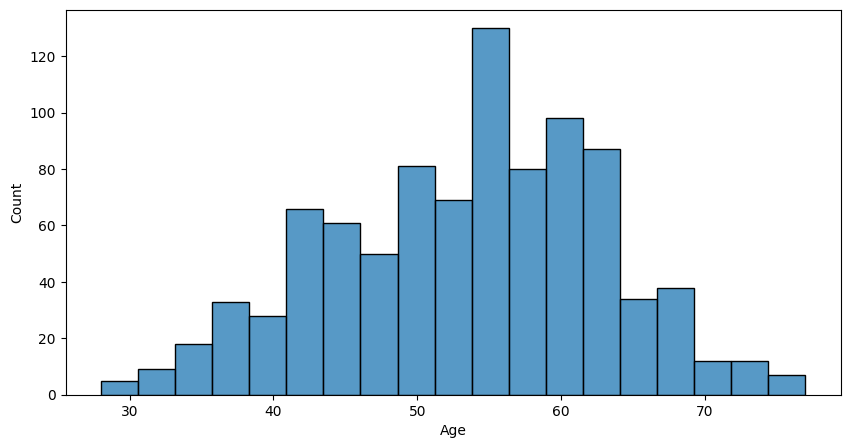

In [22]:
#checks the destribution of age
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,5))
sns.histplot(data,x='Age')
plt.show()

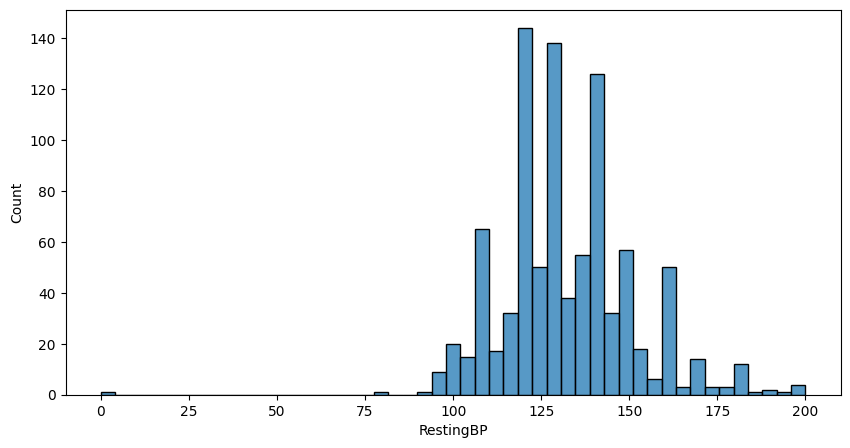

In [23]:
#checks the destribution of RestingBP
plt.figure(figsize=(10,5))
sns.histplot(data,x='RestingBP')
plt.show()

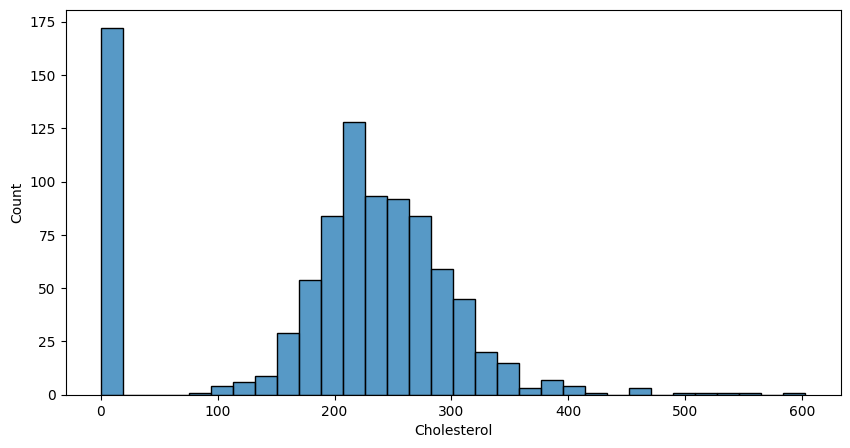

In [24]:
#checks the destribution of Cholestrol
plt.figure(figsize=(10,5))
sns.histplot(data,x='Cholesterol')
plt.show()

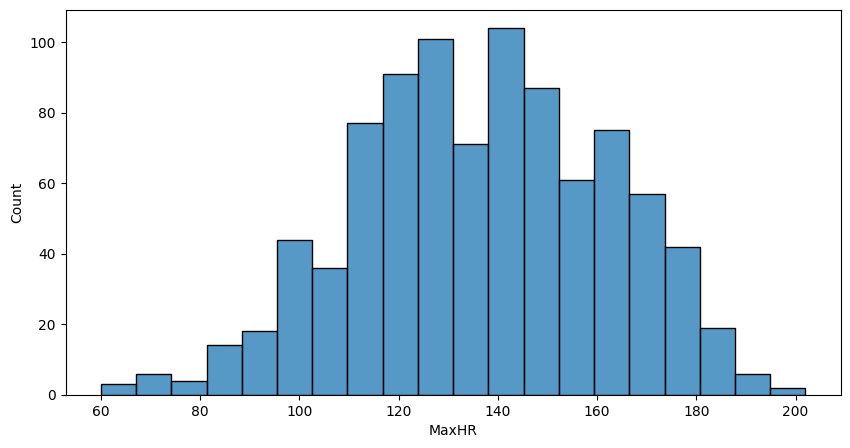

In [25]:
#checks the destribution of MaxHR
plt.figure(figsize=(10,5))
sns.histplot(data,x='MaxHR')
plt.show()

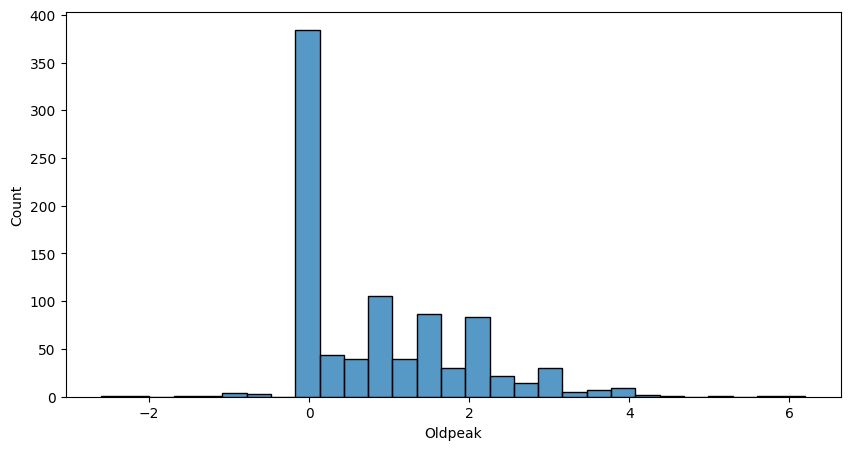

In [26]:
#checks the destribution of oldpeak
plt.figure(figsize=(10,5))
sns.histplot(data,x='Oldpeak')
plt.show()

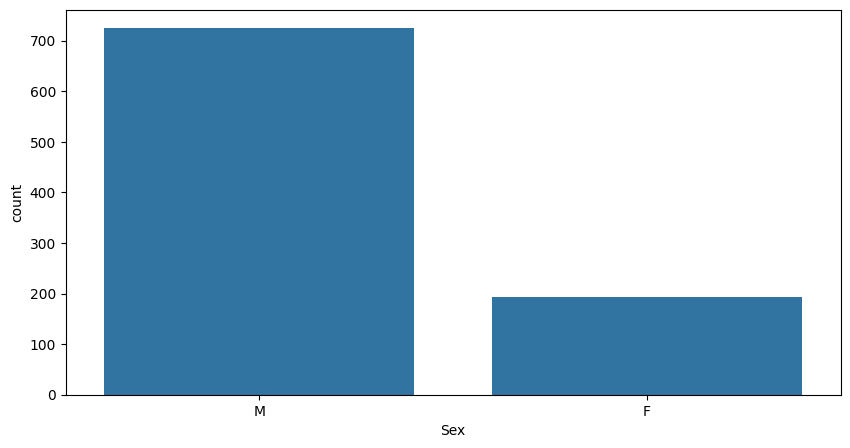

In [27]:
# count of male and female
plt.figure(figsize=(10,5))
sns.countplot(data,x='Sex')
plt.show()

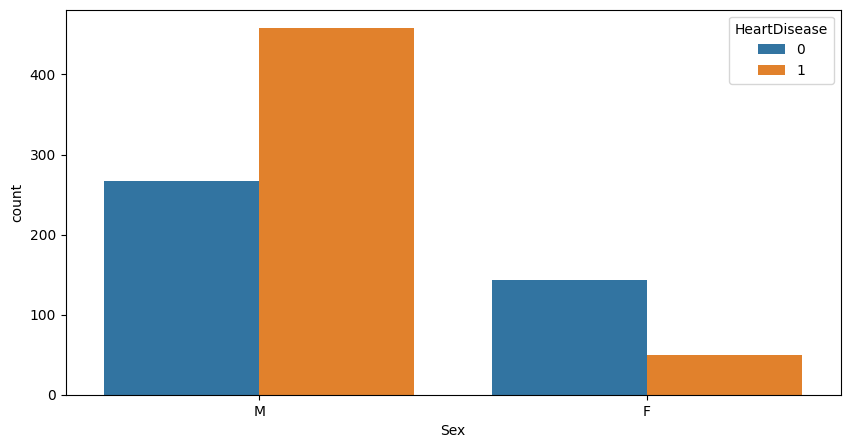

In [28]:
# count of male and female
plt.figure(figsize=(10,5))
sns.countplot(data,x='Sex',hue='HeartDisease')
plt.show()

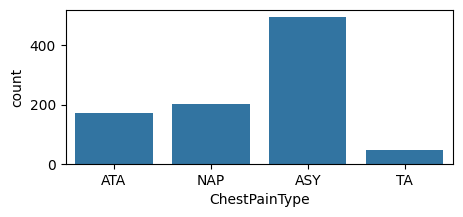

In [29]:
#coun t of chestpain
plt.figure(figsize=(5,2))
sns.countplot(data,x='ChestPainType')
plt.show()

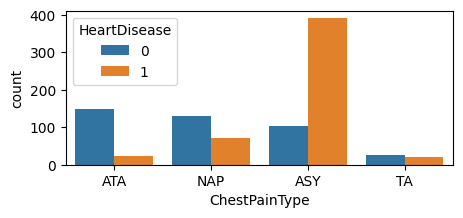

In [30]:
#coun t of chestpain
plt.figure(figsize=(5,2))
sns.countplot(data,x='ChestPainType',hue='HeartDisease')
plt.show()

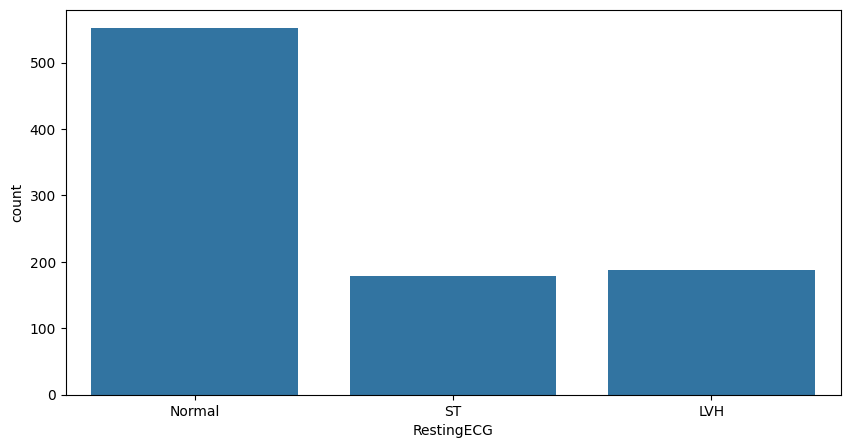

In [31]:
#count of RestingECG
plt.figure(figsize=(10,5))
sns.countplot(data,x='RestingECG')
plt.show()

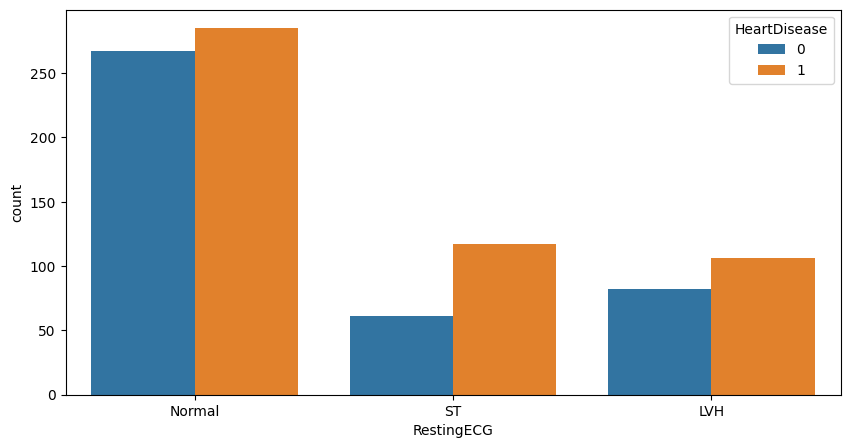

In [32]:
#count of RestingECG
plt.figure(figsize=(10,5))
sns.countplot(data,x='RestingECG',hue='HeartDisease')
plt.show()

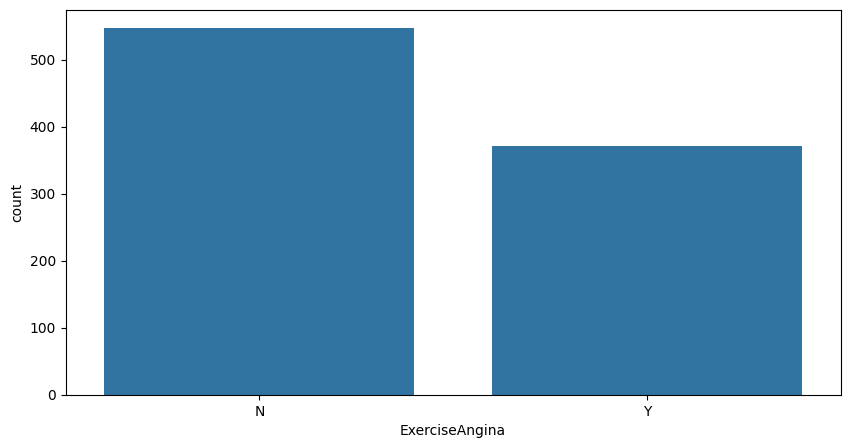

In [33]:
#count of ExeriseAngina
plt.figure(figsize=(10,5))
sns.countplot(data,x='ExerciseAngina')
plt.show()

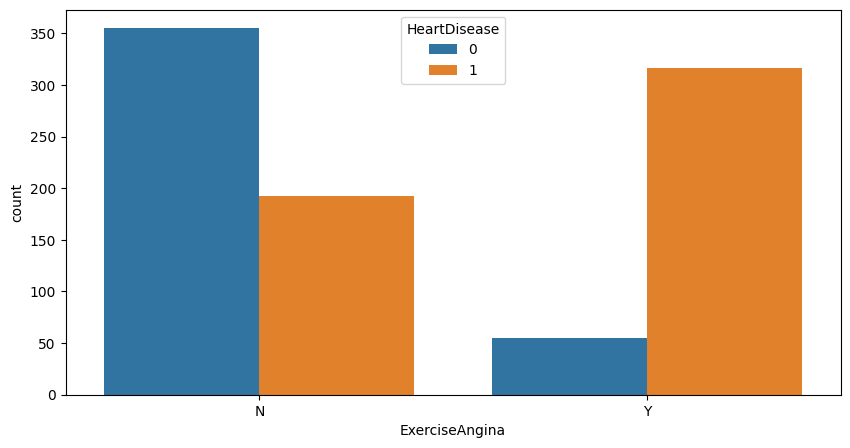

In [34]:
plt.figure(figsize=(10,5))
sns.countplot(data,x='ExerciseAngina',hue='HeartDisease')
plt.show()

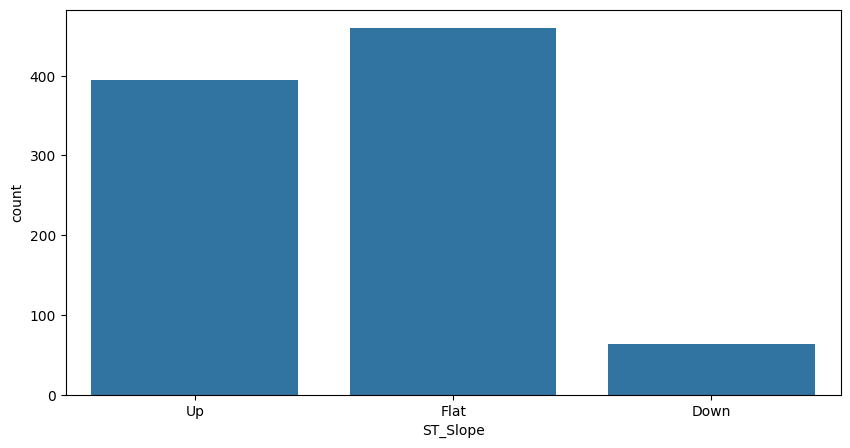

In [35]:
#ST_Slop
plt.figure(figsize=(10,5))
sns.countplot(data,x='ST_Slope')
plt.show()

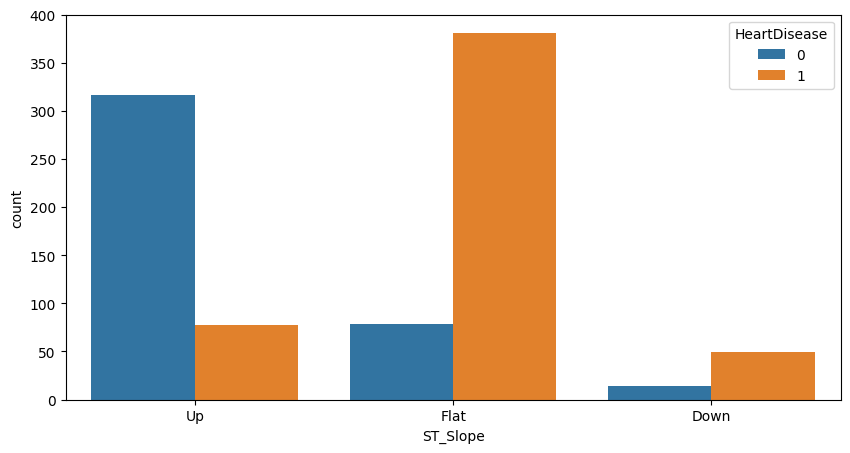

In [36]:
plt.figure(figsize=(10,5))
sns.countplot(data,x='ST_Slope',hue='HeartDisease')
plt.show()

**Bivariate Analysis**

<Axes: xlabel='Age', ylabel='Cholesterol'>

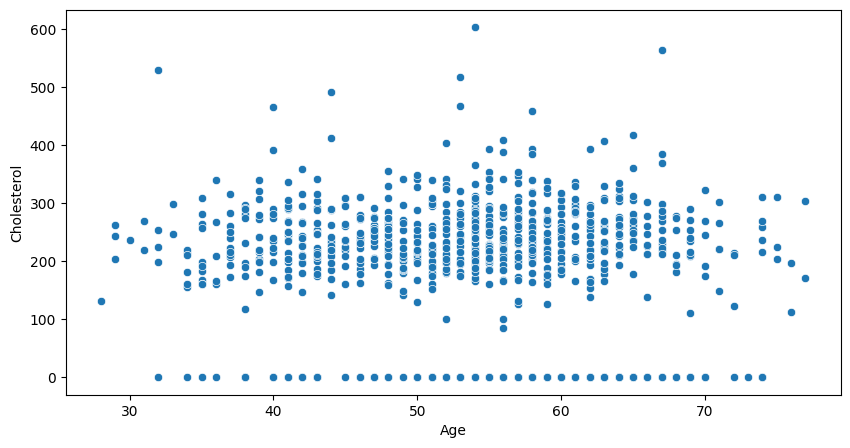

In [37]:
# age vs cholesterol
plt.figure(figsize=(10,5))
sns.scatterplot(data,x='Age',y='Cholesterol')

<Axes: xlabel='Age', ylabel='RestingBP'>

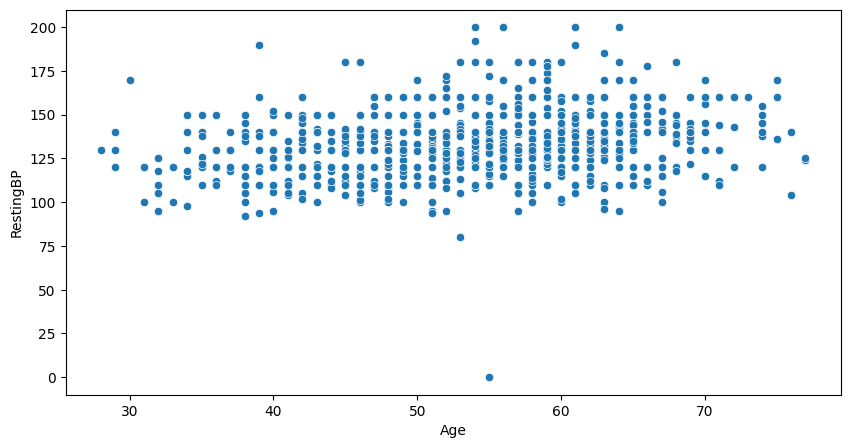

In [38]:
#age vs RestingBP
plt.figure(figsize=(10,5))
sns.scatterplot(data,x='Age',y='RestingBP')

<Axes: xlabel='Age', ylabel='MaxHR'>

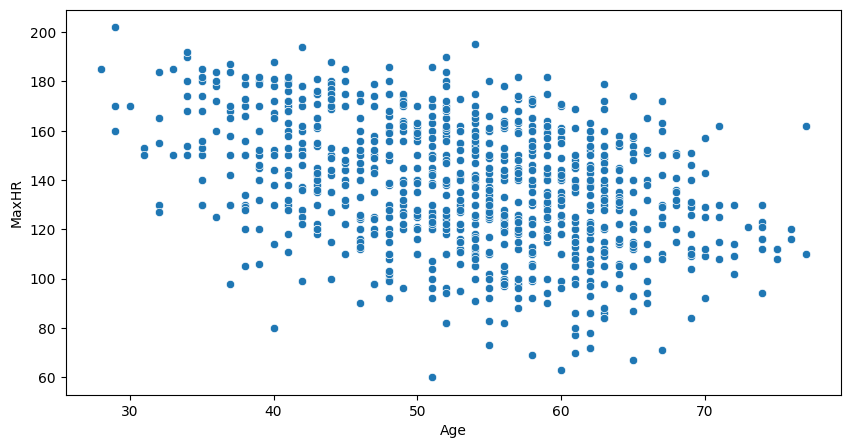

In [39]:
#age vs MaxHR
plt.figure(figsize=(10,5))
sns.scatterplot(data,x='Age',y='MaxHR')

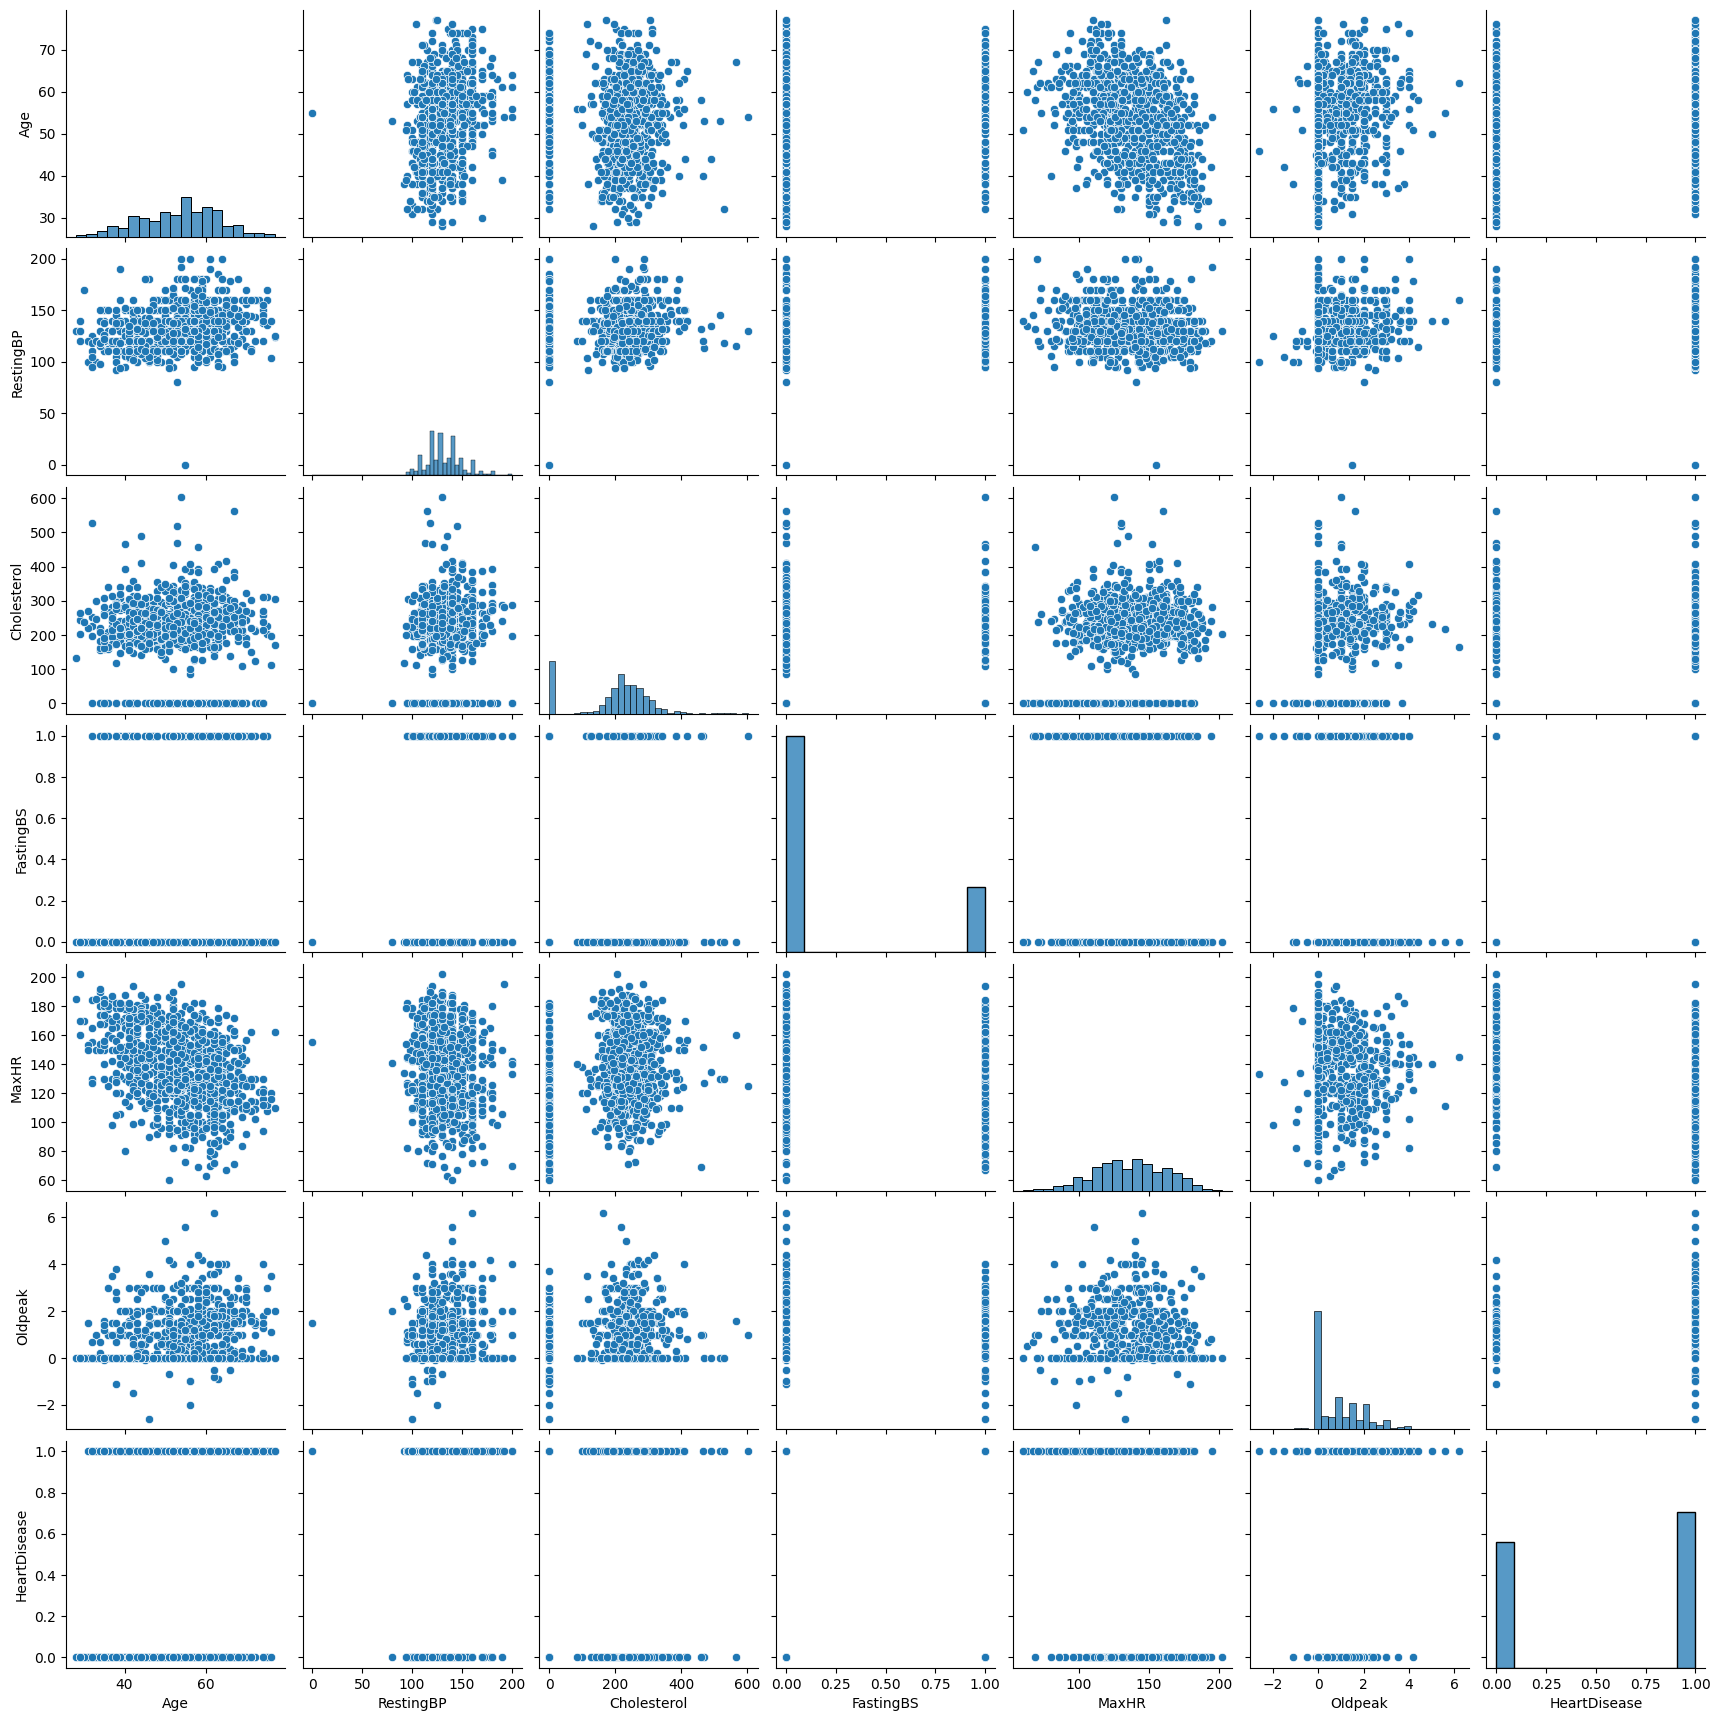

In [40]:
sns.pairplot(data)

***Heat Map***

In [41]:
num_cols=data.select_dtypes(include='number')
num_cols.corr()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
Age,1.000000,0.254399,-0.095282,0.198039,-0.382045,0.258612,0.282039
RestingBP,0.254399,1.000000,0.100893,0.070193,-0.112135,0.164803,0.107589
Cholesterol,-0.095282,0.100893,1.000000,-0.260974,0.235792,0.050148,-0.232741
FastingBS,0.198039,0.070193,-0.260974,1.000000,-0.131438,0.052698,0.267291
MaxHR,-0.382045,-0.112135,0.235792,-0.131438,1.000000,-0.160691,-0.400421
Oldpeak,0.258612,0.164803,0.050148,0.052698,-0.160691,1.000000,0.403951
HeartDisease,0.282039,0.107589,-0.232741,0.267291,-0.400421,0.403951,1.000000


<Axes: >

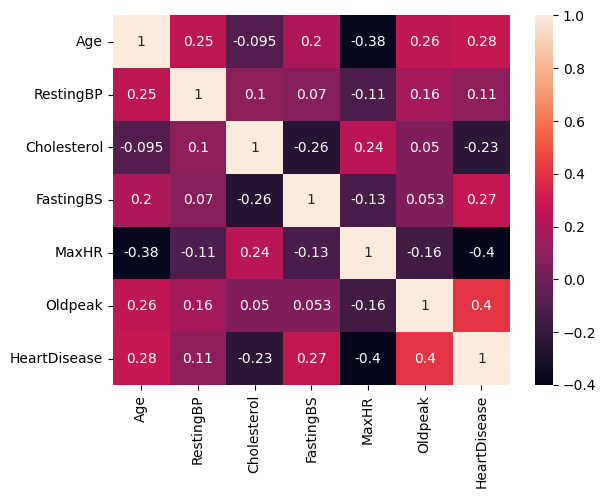

In [42]:
sns.heatmap(num_cols.corr(),annot=True)

**Handle Outlears**

<Axes: xlabel='Oldpeak'>

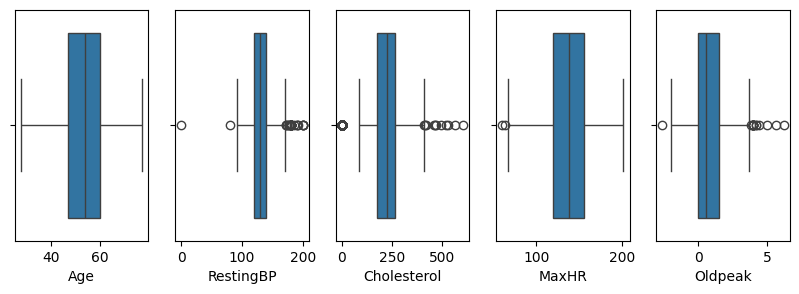

In [43]:
fig,ax=plt.subplots(1,5,figsize=(10,3))
sns.boxplot(data,x='Age',ax=ax[0])
sns.boxplot(data,x='RestingBP',ax=ax[1])
sns.boxplot(data,x='Cholesterol',ax=ax[2])
sns.boxplot(data,x='MaxHR',ax=ax[3])
sns.boxplot(data,x='Oldpeak',ax=ax[4])


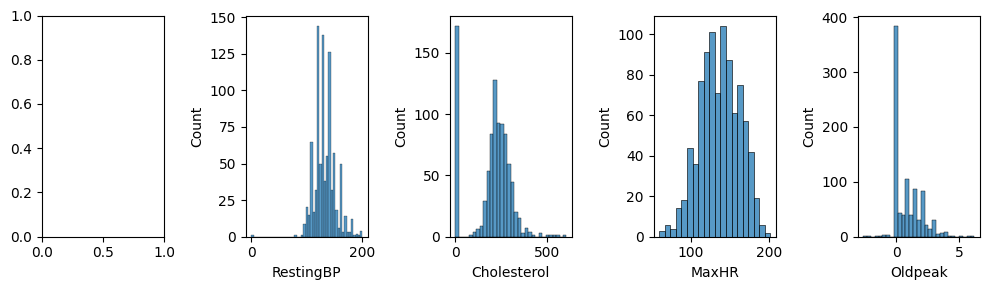

In [44]:
#checks distribution
fig,ax=plt.subplots(1,5,figsize=(10,3))
sns.histplot(data,x='RestingBP',ax=ax[1])
sns.histplot(data,x='Cholesterol',ax=ax[2])
sns.histplot(data,x='MaxHR',ax=ax[3])
sns.histplot(data,x='Oldpeak',ax=ax[4])
plt.tight_layout()

In [45]:
A=['RestingBP','Cholesterol','MaxHR','Oldpeak']
for x in A:
  print(x,'-->',data[x].skew())

RestingBP --> 0.1798393100516288
Cholesterol --> -0.6100864307268192
MaxHR --> -0.14435941846180994
Oldpeak --> 1.0228720218107528


- RestingBP,MaxHR distribution is normal as it skew is between[-0.5,0.5]
- Choleterol and Oldpeak is skewed

**cholestral and Oldpeak**

cholestral

In [46]:
Q1=data.loc[:,'Cholesterol'].quantile(0.25)
Q3=data.loc[:,'Cholesterol'].quantile(0.75)
IQR=Q3-Q1
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR

In [47]:
data[(data.loc[:,'Cholesterol']>upper_limit)|(data.loc[:,'Cholesterol']<lower_limit)]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
28,53,F,ATA,113,468,0,Normal,127,N,0.0,Up,0
30,53,M,NAP,145,518,0,Normal,130,N,0.0,Flat,1
69,44,M,ASY,150,412,0,Normal,170,N,0.0,Up,0
76,32,M,ASY,118,529,0,Normal,130,N,0.0,Flat,1
103,40,M,ASY,120,466,1,Normal,152,Y,1.0,Flat,1
...,...,...,...,...,...,...,...,...,...,...,...,...
535,56,M,ASY,130,0,0,LVH,122,Y,1.0,Flat,1
536,62,M,NAP,133,0,1,ST,119,Y,1.2,Flat,1
616,67,F,NAP,115,564,0,LVH,160,N,1.6,Flat,0
667,65,F,NAP,140,417,1,LVH,157,N,0.8,Up,0


In [58]:
len(data[(data['Cholesterol'] > upper_limit) | (data['Cholesterol'] < lower_limit)]) / len(data) * 100

89.2156862745098

Oldpeak

In [ ]:
#Oldpeak use IQR method
Q1=data.loc[:,'Oldpeak'].quantile(0.25)
Q3=data.loc[:,'Oldpeak'].quantile(0.75)
IQR=Q3-Q1
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR

In [55]:
data[(data.loc[:,'Oldpeak']>upper_limit)|(data.loc[:,'Oldpeak']<lower_limit)]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,RstingBP
0,40,M,ATA,140,289,0,Normal,172.0,N,0.0,Up,0,NaN
1,49,F,NAP,160,180,0,Normal,156.0,N,1.0,Flat,1,NaN
2,37,M,ATA,130,283,0,ST,98.0,N,0.0,Up,0,NaN
3,48,F,ASY,138,214,0,Normal,108.0,Y,1.5,Flat,1,NaN
4,54,M,NAP,150,195,0,Normal,122.0,N,0.0,Up,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132.0,N,1.2,Flat,1,NaN
914,68,M,ASY,144,193,1,Normal,141.0,N,3.4,Flat,1,NaN
915,57,M,ASY,130,131,0,Normal,115.0,Y,1.2,Flat,1,NaN
916,57,F,ATA,130,236,0,LVH,174.0,N,0.0,Flat,1,NaN


In [59]:
len(data[(data.loc[:,'Oldpeak']>upper_limit)|(data.loc[:,'Oldpeak']<lower_limit)])/len(data)*100

100.0

In [62]:
data.loc[(data['Oldpeak'] > upper_limit) | (data['Oldpeak'] < lower_limit), 'Oldpeak'] = data['Oldpeak'].median()

**ResingBP**

In [52]:
mean_val=data.loc[:,'RestingBP'].mean()
std_val=data.loc[:,'RestingBP'].std()
lower_limit=mean_val-3*std_val
upper_limit=mean_val+(3*std_val)

In [53]:
data[(data.loc[:,'RestingBP']>upper_limit)|(data.loc[:,'RestingBP']<lower_limit)]


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
109,39,M,ATA,190,241,0,Normal,106.0,N,0.0,Up,0
241,54,M,ASY,200,198,0,Normal,142.0,Y,2.0,Flat,1
365,64,F,ASY,200,0,0,Normal,140.0,Y,1.0,Flat,1
399,61,M,NAP,200,0,1,ST,70.0,N,0.0,Flat,1
449,55,M,NAP,0,0,0,Normal,155.0,N,1.5,Flat,1
592,61,M,ASY,190,287,1,LVH,150.0,Y,2.0,Down,1
732,56,F,ASY,200,288,1,LVH,133.0,Y,4.0,Down,1
759,54,M,ATA,192,283,0,LVH,195.0,N,0.0,Up,1


In [54]:
data.loc[(data.loc[:,'RestingBP']>upper_limit)|
 (data.loc[:,'RestingBP']<lower_limit),'RstingBP']=data.loc[:,'RestingBP'].mean()


**MaxHR**

In [49]:
mean_val=data.loc[:,'MaxHR'].mean()
std_val=data.loc[:,'MaxHR'].std()
lower_limit=mean_val-3*std_val
upper_limit=mean_val+(3*std_val)

In [50]:
data[(data.loc[:,'MaxHR']>upper_limit)|(data.loc[:,'MaxHR']<lower_limit)]


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
390,51,M,ASY,140,0,0,Normal,60,N,0.0,Flat,1


In [51]:
data.loc[(data.loc[:,'MaxHR']>upper_limit)|
 (data.loc[:,'MaxHR']<lower_limit),'MaxHR']=data.loc[:,'MaxHR'].mean()


/tmp/ipykernel_274/3634711647.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '136.80936819172112' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[(data.loc[:,'MaxHR']>upper_limit)|
